In [19]:
import pandas as pd
import numpy as np
import scikitplot as skplt
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from imblearn.under_sampling import RandomUnderSampler


In [20]:
path = '../01 - R and Python/Churn_Banking_Modeling_ENG.csv'
dataset = pd.read_csv(path)

In [21]:
# the target variable is key for our analysis
dataset = dataset.rename(columns={'flag_request_closure': 'Target'})

In [22]:
# We want the target variable values to be either 0 or 1
dataset.replace({'Target': {'si': 1, 'no': 0}}, inplace=True)
dataset['Target'] = dataset['Target'].astype(int)

In [23]:
# for sake of simplicity
# here we choose to just work on numerical variables
var_to_use = [
    'Target', 'amt_cust_value', 'flag_online_acc_opening',
       'flag_mult_account_ownership', 'num_age',
       'num_year_first_account',
       'amt_pricing_fee', 'amt_transfer_vs_competitors',
       'amt_tranfers_vs_no_competitors', 'num_existing_services',
       'flag_salary_deposit', 'amt_credit_card_spending',
       'amt_debit_card_spending', 'num_website_access_count',
       'num_transactions_count', 'num_trading_activities_count',
       'str_change_num_utilities', 'flag_mortgage', 'flag_loan',
       'flag_internal_tranfers', 'flag_request_info_closure',
       'flag_loyalty_program_enrol', 'flag_call_center_contact',
       'flag_salary_deposit_variation', 'num_loyalty_points',
       'amt_current_liquidity', 'amt_current_managed',
       'amt_current_administered', 'amt_6m_current_liquidity',
       'amt_6m_current_managed', 'amt_6m_current_administered',
       'flag_outgoing_sec_tranfer', 'flag_card_rejection',
       'flag_loan_rejection', 'flag_deactivation_rid'
]

# i like to create list with all feature names (all variables except target)
# that may be useful later in constructing training datasets
features_names =  var_to_use.copy()
features_names.remove('Target')

# i remove all the variables that won't be used
dataset = dataset[var_to_use].copy() # why do we use .copy()?

# impute all missing values to zero
dataset[features_names] = dataset[features_names].fillna(0)

# create the "features" dataframe with just feature variables (remove target)
features = dataset.drop('Target', axis = 1)

# create array with target variable
target = dataset[['Target']].values


In [24]:
# in order to prevent overfitting
# we generate train and test sample
(train_X, test_X, train_y, test_y) = train_test_split(features, target, train_size=0.7, random_state=1)

In [25]:
# Let's have a look at the target variable
# we can do it by making use of some package that was made for it
print("train target count : ", Counter(train_y[:,0]))

unique, counts = np.unique(train_y[:,0], return_counts=True)

train target count :  Counter({np.int64(0): 262759, np.int64(1): 1399})


In [26]:
# We choose to perform undersampling
# we choose to set 20% as undersampling percentage
undersample = RandomUnderSampler(sampling_strategy=0.2)
# we generate balanced train dataset
train_X_bal, train_y_bal = undersample.fit_resample(train_X, train_y)
# why are we not undersampling the test set?

In [27]:
train_X.shape # (264158, 34)
train_X_bal.shape # (8394, 34)
train_y_bal.shape # (8394,)

(8394,)

### Grid search

In [28]:
def evaluate_model(model, X_test, y_test):

    #performance metrics
    y_pred    = model.predict(X_test)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    score_test = model.predict_proba(test_X)
    return {
        "precision": round(precision, 4),
        "recall":    round(recall, 4),
        "f1":        round(f1, 4),
        "score_test": score_test,
    }

### Baseline Model

In [29]:
# we start training a tree
# we define the classifier
# and we set an hyperameter - tree must not be deeper than 5 levels
# dtc3 = DecisionTreeClassifier(min_samples_leaf=50)
dtc3 = DecisionTreeClassifier(max_depth=4, random_state=42)
# we train the classifier
dtc3.fit(train_X_bal, train_y_bal)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [30]:
# again, we get predictions and scores on  test dataset
label_pred_test_3 = dtc3.predict(test_X)
score_test_3 = dtc3.predict_proba(test_X)
# (less useful) - predict on trainign dataset
label_pred_train_3 = dtc3.predict(train_X_bal)
score_train_3 = dtc3.predict_proba(train_X_bal)

In [31]:
cm_test_3=confusion_matrix(test_y,label_pred_test_3)
print(cm_test_3)

[[105931   6696]
 [   309    275]]


In [32]:
#calculate the performance metrics for the baseline performance benchmark
baseline_metrics = evaluate_model(dtc3, test_X, test_y)

baseline_row = pd.DataFrame([{
    "dataset":          "undersampled (baseline dtc3)",
    "max_depth":        4,
    "min_samples_leaf": 1,
    **baseline_metrics
}])

print("Baseline dtc3:", baseline_metrics)

Baseline dtc3: {'precision': 0.0394, 'recall': 0.4709, 'f1': 0.0728, 'score_test': array([[0.93472906, 0.06527094],
       [0.93472906, 0.06527094],
       [0.98950233, 0.01049767],
       ...,
       [0.45289855, 0.54710145],
       [0.84802432, 0.15197568],
       [0.80508475, 0.19491525]], shape=(113211, 2))}


<Axes: title={'center': 'ROC Curve'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

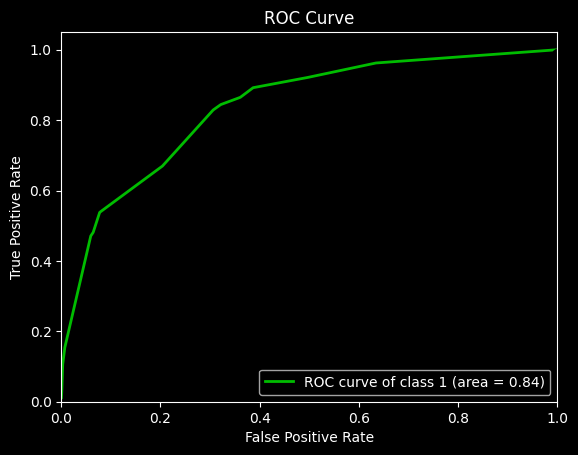

In [33]:
# now that we have a little better tree let's continue evaluating
# let's plot ROC curve
skplt.metrics.plot_roc(test_y, score_test_3, title = "ROC Curve", plot_micro  = False, plot_macro  = False, classes_to_plot=[1] )

<Axes: title={'center': 'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

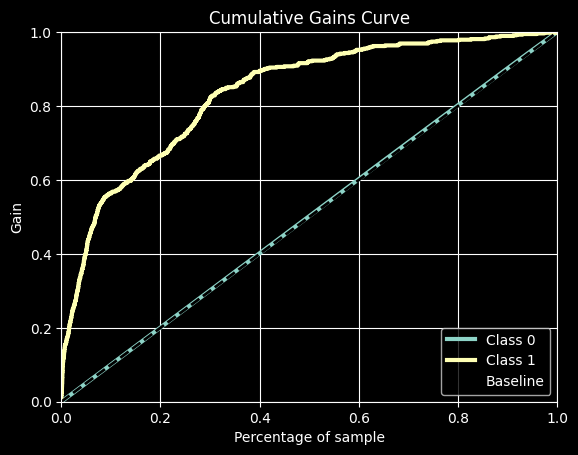

In [34]:
# in case i want to plot the cumulative gains chart
skplt.metrics.plot_cumulative_gain(test_y, score_test_3)

### Hyperparameters test

In [35]:
# define the possible values for the parameters
max_depth_values      = [2, 5, 10, 15, 20, 25, 30, 35]
min_samples_leaf_values = [1, 5, 10, 15, 20, 25, 50, 100]

In [37]:
results = []

datasets = {
    #"original":     (train_X,     train_y),
    "undersampled": (train_X_bal, train_y_bal),
}

#test the performance of both the normal and undersampled dataframe
for dataset_name, (X_train, y_train) in datasets.items():
    for md in max_depth_values:
        for msl in min_samples_leaf_values:

            model = DecisionTreeClassifier(
                max_depth=md,
                min_samples_leaf=msl,
                random_state=42
            )
            model.fit(X_train, y_train)


            metrics = evaluate_model(model, test_X, test_y)
            metrics.update({
                "dataset":          dataset_name,
                "max_depth":        md,
                "min_samples_leaf": msl,
            })
            results.append(metrics)

results_df = pd.DataFrame(results, columns=[
    "dataset", "max_depth", "min_samples_leaf",
    "precision", "recall", "f1", "score_test"
])

In [38]:
results_df

,dataset,max_depth,min_samples_leaf,precision,recall,f1,score_test
27,undersampled,15,15,0.0400,0.5428,0.0746,"[[1.0, 0.0], [0.96, 0.04], [1.0, 0.0], [1.0, 0..."
59,undersampled,35,15,0.0376,0.5411,0.0703,"[[1.0, 0.0], [0.96, 0.04], [1.0, 0.0], [1.0, 0..."
43,undersampled,25,15,0.0376,0.5411,0.0703,"[[1.0, 0.0], [0.96, 0.04], [1.0, 0.0], [1.0, 0..."
35,undersampled,20,15,0.0376,0.5411,0.0703,"[[1.0, 0.0], [0.96, 0.04], [1.0, 0.0], [1.0, 0..."
51,undersampled,30,15,0.0376,0.5411,0.0703,"[[1.0, 0.0], [0.96, 0.04], [1.0, 0.0], [1.0, 0..."
...,...,...,...,...,...,...,...
23,undersampled,10,100,0.0458,0.3801,0.0818,"[[0.8073394495412844, 0.1926605504587156], [1...."
47,undersampled,25,100,0.0458,0.3801,0.0818,"[[0.8073394495412844, 0.1926605504587156], [1...."
39,undersampled,20,100,0.0458,0.3801,0.0818,"[[0.8073394495412844, 0.1926605504587156], [1...."
55,undersampled,30,100,0.0458,0.3801,0.0818,"[[0.8073394495412844, 0.1926605504587156], [1...."


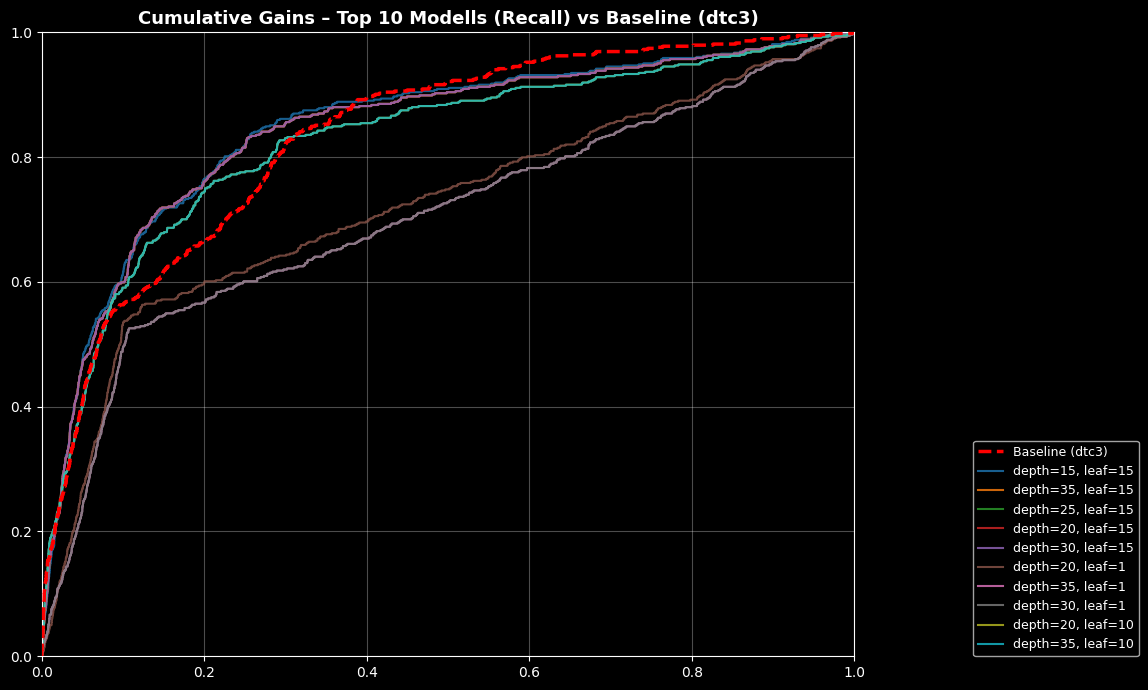

In [48]:
# Top 10 recall
top10 = results_df.sort_values("recall", ascending=False).head(10)

colors = [cm.tab10(i / 10) for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 7))


# --- Baseline: dtc3 ---
baseline_probas = score_test_3
sorted_indices_b = np.argsort(baseline_probas[:, 1])[::-1]
sorted_labels_b = np.array(test_y)[sorted_indices_b]
total_pos = np.sum(test_y == 1)
gains_b = np.cumsum(sorted_labels_b == 1) / total_pos
percentages_b = np.arange(1, len(sorted_labels_b) + 1) / len(sorted_labels_b)

ax.plot(percentages_b, gains_b,
        color="red", linewidth=2.5, linestyle="--",
        label="Baseline (dtc3)", zorder=5)

# --- Top 10 modells ---
for i, ((_, row), color) in enumerate(zip(top10.iterrows(), colors)):
    y_probas = row["score_test"]
    name = f"depth={row['max_depth']}, leaf={row['min_samples_leaf']}"

    sorted_indices = np.argsort(y_probas[:, 1])[::-1]
    sorted_labels = np.array(test_y)[sorted_indices]

    gains = np.cumsum(sorted_labels == 1) / total_pos
    percentages = np.arange(1, len(sorted_labels) + 1) / len(sorted_labels)

    ax.plot(percentages, gains, label=name, color=color,
            linewidth=1.5, alpha=0.8)

ax.set_xlabel("Percentage of sample", fontsize=12)
ax.set_ylabel("Cumulative Gains", fontsize=12)
ax.set_title("Cumulative Gains – Top 10 Modells (Recall) vs Baseline (dtc3)",
             fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=9,
          bbox_to_anchor=(1.35, 0), borderaxespad=0)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

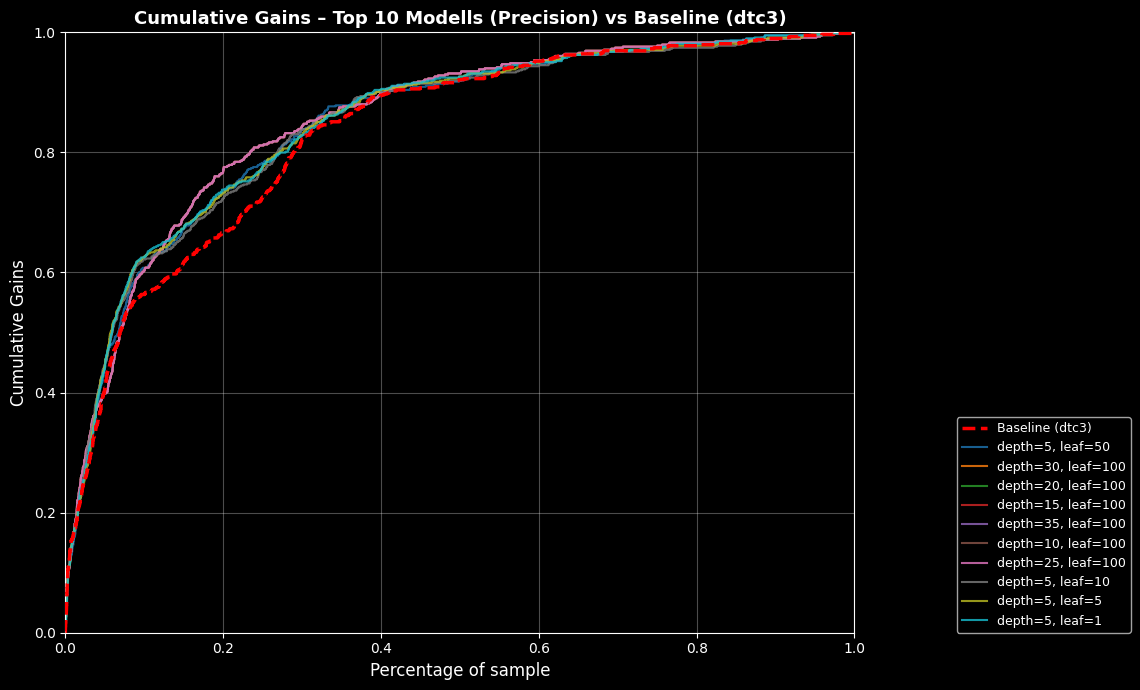

In [50]:
# Top 10 recall
top10 = results_df.sort_values("precision", ascending=False).head(10)

colors = [cm.tab10(i / 10) for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 7))


# --- Baseline: dtc3 ---
baseline_probas = score_test_3
sorted_indices_b = np.argsort(baseline_probas[:, 1])[::-1]
sorted_labels_b = np.array(test_y)[sorted_indices_b]
total_pos = np.sum(test_y == 1)
gains_b = np.cumsum(sorted_labels_b == 1) / total_pos
percentages_b = np.arange(1, len(sorted_labels_b) + 1) / len(sorted_labels_b)

ax.plot(percentages_b, gains_b,
        color="red", linewidth=2.5, linestyle="--",
        label="Baseline (dtc3)", zorder=5)

# --- Top 10 modells ---
for i, ((_, row), color) in enumerate(zip(top10.iterrows(), colors)):
    y_probas = row["score_test"]
    name = f"depth={row['max_depth']}, leaf={row['min_samples_leaf']}"

    sorted_indices = np.argsort(y_probas[:, 1])[::-1]
    sorted_labels = np.array(test_y)[sorted_indices]

    gains = np.cumsum(sorted_labels == 1) / total_pos
    percentages = np.arange(1, len(sorted_labels) + 1) / len(sorted_labels)

    ax.plot(percentages, gains, label=name, color=color,
            linewidth=1.5, alpha=0.8)

ax.set_xlabel("Percentage of sample", fontsize=12)
ax.set_ylabel("Cumulative Gains", fontsize=12)
ax.set_title("Cumulative Gains – Top 10 Modells (Precision) vs Baseline (dtc3)",
             fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=9,
          bbox_to_anchor=(1.35, 0), borderaxespad=0)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

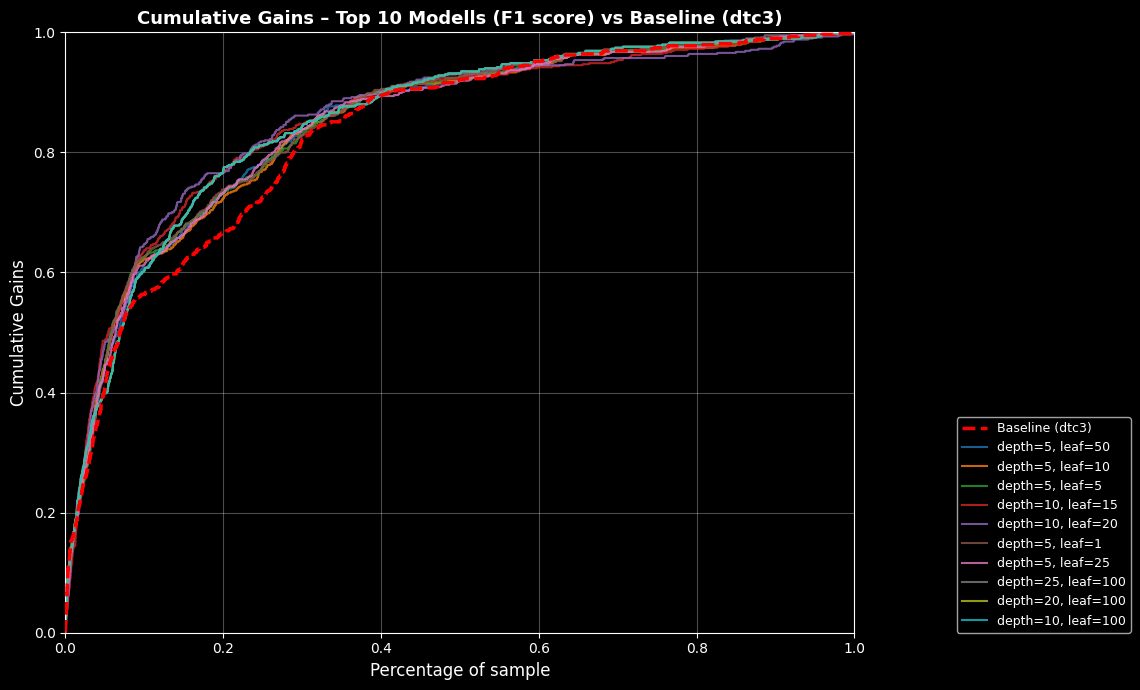

In [49]:
# Top 10 recall
top10 = results_df.sort_values("f1", ascending=False).head(10)

colors = [cm.tab10(i / 10) for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 7))


# --- Baseline: dtc3 ---
baseline_probas = score_test_3
sorted_indices_b = np.argsort(baseline_probas[:, 1])[::-1]
sorted_labels_b = np.array(test_y)[sorted_indices_b]
total_pos = np.sum(test_y == 1)
gains_b = np.cumsum(sorted_labels_b == 1) / total_pos
percentages_b = np.arange(1, len(sorted_labels_b) + 1) / len(sorted_labels_b)

ax.plot(percentages_b, gains_b,
        color="red", linewidth=2.5, linestyle="--",
        label="Baseline (dtc3)", zorder=5)

# --- Top 10 modells ---
for i, ((_, row), color) in enumerate(zip(top10.iterrows(), colors)):
    y_probas = row["score_test"]
    name = f"depth={row['max_depth']}, leaf={row['min_samples_leaf']}"

    sorted_indices = np.argsort(y_probas[:, 1])[::-1]
    sorted_labels = np.array(test_y)[sorted_indices]

    gains = np.cumsum(sorted_labels == 1) / total_pos
    percentages = np.arange(1, len(sorted_labels) + 1) / len(sorted_labels)

    ax.plot(percentages, gains, label=name, color=color,
            linewidth=1.5, alpha=0.8)

ax.set_xlabel("Percentage of sample", fontsize=12)
ax.set_ylabel("Cumulative Gains", fontsize=12)
ax.set_title("Cumulative Gains – Top 10 Modells (F1 score) vs Baseline (dtc3)",
             fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=9,
          bbox_to_anchor=(1.35, 0), borderaxespad=0)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()